In [3]:
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import pandas
import numpy
import torch.nn.functional
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import yfinance
import matplotlib.pyplot as plt
import requests
from datetime import datetime
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings(action='ignore')
## Prepare Data set
warnings.filterwarnings(action='ignore')
pandas.set_option('display.float_format', '{:.4f}'.format)

In [17]:
loan_test_data=pandas.read_csv('/Users/kbh/Downloads/lending club/lending_club_clean_2020_test.csv')

In [7]:
temp_result=pandas.read_csv('/Users/kbh/Downloads/lending club/predictions.csv')

In [33]:
temp_result.columns

Index(['id', 'dnn_pred', 'xgboost_pred'], dtype='object')

In [29]:
loan_test_data_out_current=loan_test_data[loan_test_data['loan_status']!='Current']

In [30]:
loan_test_data_in_current=loan_test_data[loan_test_data['loan_status']=='Current']

In [37]:
result=pandas.merge(loan_test_data_out_current,temp_result,on='id')

In [44]:
# result.to_csv('/Users/kbh/Downloads/lending club/test_predict_out_curren.csv',index=False)

In [327]:
result['real_target']=result['total_rec_prncp']/result['funded_amnt']

In [163]:
# ITE ETF 데이터를 다운로드
ticker = 'SHY'
ite = yfinance.Ticker(ticker)

# 2004년부터 현재까지의 배당금 정보
dividends = ite.dividends['2004-01-01':]

# 2007년부터 현재까지의 가격 데이터 다운로드
etf_data = ite.history(start="2004-01-01")
etf_data['month']=pandas.to_datetime(etf_data.index.strftime('%Y-%m-%d'))
# 모든 열 출력 설정
pandas.set_option('display.max_columns', None)

# 모든 행 출력 설정
pandas.set_option('display.max_rows', None)

In [164]:
api_key = 'ca552aba80a8399206569337091186c9'

# FRED에서 3년 및 5년 만기 미국 국채 수익률 데이터 가져오기
def fetch_fred_data(series_id, api_key, start_date, end_date):
    url = f'https://api.stlouisfed.org/fred/series/observations'
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
        'observation_start': start_date,
        'observation_end': end_date
    }
    response = requests.get(url, params=params)
    data = response.json()
    df = pandas.DataFrame(data['observations'])
    df['date'] = pandas.to_datetime(df['date'])
    
    # "."을 NaN으로 변경하고 숫자로 변환
    df['value'] = df['value'].replace('.', pandas.NA)
    df['rate'] = pandas.to_numeric(df['value'], errors='coerce')  # 에러 발생시 NaN으로 대체
    
    return df

# 데이터 가져오기
start_date = '2006-12-30'
end_date = '2020-12-31'

# 3년 만기 미국 국채 수익률
temp_bond3yr = fetch_fred_data('DGS3', api_key, start_date, end_date)
temp_bond3yr['rate']=temp_bond3yr['rate'].ffill()
# 5년 만기 미국 국채 수익률
temp_bond5yr = fetch_fred_data('DGS5', api_key, start_date, end_date)
temp_bond5yr['rate']=temp_bond5yr['rate'].ffill()

In [165]:
temp_bond5yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond5yr['date'].min(), end=temp_bond5yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond5yr = pandas.DataFrame(pandas.merge(df_full, temp_bond5yr, on='date', how='left'))
bond5yr['date']=bond5yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond5yr.ffill(inplace=True)
bond5yr.bfill(inplace=True)

In [166]:
temp_bond3yr.drop(['realtime_start','realtime_end','value'],inplace=True,axis=1)

full_date_range = pandas.date_range(start=temp_bond3yr['date'].min(), end=temp_bond3yr['date'].max())

df_full = pandas.DataFrame({'date': full_date_range})
bond3yr = pandas.merge(df_full, temp_bond3yr, on='date', how='left')
bond3yr['date']=bond3yr['date'].dt.strftime('%Y-%m-%d')
# 결측값을 이전 값으로 채우기
bond3yr.ffill(inplace=True)
bond3yr.bfill(inplace=True)

In [171]:
def calc_bond_rate(loan_data, bond3yr, bond5yr):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])  # issue_d를 datetime 형식으로 변환

    # 3년 또는 5년 채권에 따라 수익률을 결정하기 위한 기준 데이터프레임 병합
    bond3yr['date'] = pandas.to_datetime(bond3yr['date'])
    bond5yr['date'] = pandas.to_datetime(bond5yr['date'])

    # 3년과 5년 채권 데이터를 loan_data와 결합
    loans_3yr = pandas.merge(loans, bond3yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_3yr'))
    loans_5yr = pandas.merge(loans, bond5yr[['date', 'rate']], left_on='issue_d', right_on='date', how='left', suffixes=('', '_5yr'))

    # 대출 기간에 따라 3년 또는 5년 채권 수익률을 선택
    loans['bond_rate'] = numpy.where(
        loans['term'] == 36,  # 조건: 3년 대출
        loans_3yr['rate'],  # 3년 채권 수익률 선택
        loans_5yr['rate']  # 5년 채권 수익률 선택
    )

    # 수익률 계산: (1 + rate / 100)
    loans['bond_rate'] = 1 + loans['bond_rate'] / 100

    return loans[['bond_rate']]

In [173]:
def calc_etf_rate(loan_data, etf_data):
    loans = loan_data[['issue_d','term']]
    loans['issue_d'] = pandas.to_datetime(loans['issue_d'])
    
    loans['etf_start_day'] = numpy.where(
        loans['term'] == 36,
        loans['issue_d'] - pandas.DateOffset(years=3),
        loans['issue_d'] - pandas.DateOffset(years=5)
    )
    loans['etf_end_day'] = loans['issue_d']
    
    # ETF 수익률을 계산할 열 추가
    loans['etf_rate'] = 0.0

    # 각 대출에 대해 수익률 계산
    for i, row in loans.iterrows():
        etf_start_day = row['etf_start_day']
        etf_end_day = row['etf_end_day']
        revenue_data = etf_data[(etf_data['month'] >= etf_start_day) & (etf_data['month'] <= etf_end_day)]
        
        if not revenue_data.empty:
            open_price = revenue_data.iloc[0]['Open']
            close_price = revenue_data.iloc[-1]['Close']
            dividends_sum = revenue_data['Dividends'].sum()
            capital_gains_sum = revenue_data['Capital Gains'].sum()
            year_revenue = dividends_sum + capital_gains_sum + (close_price - open_price)
            etf_rate = year_revenue / open_price
            loans.at[i, 'etf_rate'] = etf_rate
    
    return loans
    

In [175]:
def selected_etf_bond_rate(loan_data, etf_data, bond3yr, bond5yr):
    # ETF 수익률 계산
    loans_with_etf_rate = calc_etf_rate(loan_data, etf_data)

    # 채권 수익률 계산
    loans_with_bond_rate = calc_bond_rate(loan_data, bond3yr, bond5yr)
    loans = loans_with_etf_rate.copy()
    loans['bond_rate'] = loans_with_bond_rate['bond_rate']

    # ETF 수익률과 채권 수익률 중 더 큰 값을 선택
    loans['selected_type'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        'ETF',
        'Bond'
    )
    loans['selected_rate'] = numpy.where(
        loans['etf_rate'] > loans['bond_rate'],
        loans['etf_rate'],
        loans['bond_rate']
    )

    # 최종 결과 DataFrame 생성
    result = loans[['selected_type', 'selected_rate']].rename(columns={'selected_type': 'type', 'selected_rate': 'rate'})
    result = result.reset_index(drop=True)
    return result

In [177]:
from joblib import Parallel, delayed

In [179]:
def compute_repayment_months(loan_data,target : str):
    i = loan_data['int_rate']/1200
    N = loan_data['term']
    P = loan_data['funded_amnt']
    k = loan_data[target]
    A = loan_data['installment']
    B = P
    cumulative_principal = 0
    months = 0
    if k==0 :
        return months
    while cumulative_principal <= P * k:
        interest_payment = B * i  
        principal_payment = A - interest_payment  
        cumulative_principal += principal_payment
        B -= principal_payment
        if months >= N:
            break
        months += 1 
    return months


In [145]:
result['calc_installment']=numpy.floor(result['funded_amnt']*(result['int_rate'] / 1200 * (1 + result['int_rate'] / 1200) ** result['term']) / ((1 + result['int_rate'] / 1200) ** result['term'] - 1))

In [329]:
result['original_result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months)(row,'real_target') for _, row in result.iterrows())

In [85]:
result['DNN_result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months)(row,'dnn_pred') for _, row in result.iterrows())

In [86]:
result['xgboost_result'] = Parallel(n_jobs=-1)(delayed(compute_repayment_months)(row,'xgboost_pred') for _, row in result.iterrows())

In [331]:
result['predict_DNN_rate']=(result['calc_installment']*result['DNN_result'])/result['funded_amnt']
result['predict_xgboost_rate']=(result['calc_installment']*result['xgboost_result'])/result['funded_amnt']
result['non_marketing_rate']=(result['calc_installment']*result['original_result'])/result['funded_amnt']

In [333]:
result['real_rate']=result['total_pymnt']/result['funded_amnt']

In [335]:
result['non_marketing_rate'].mean()

1.087500875573381

In [337]:
result['real_rate'].mean()

1.0341972127963703

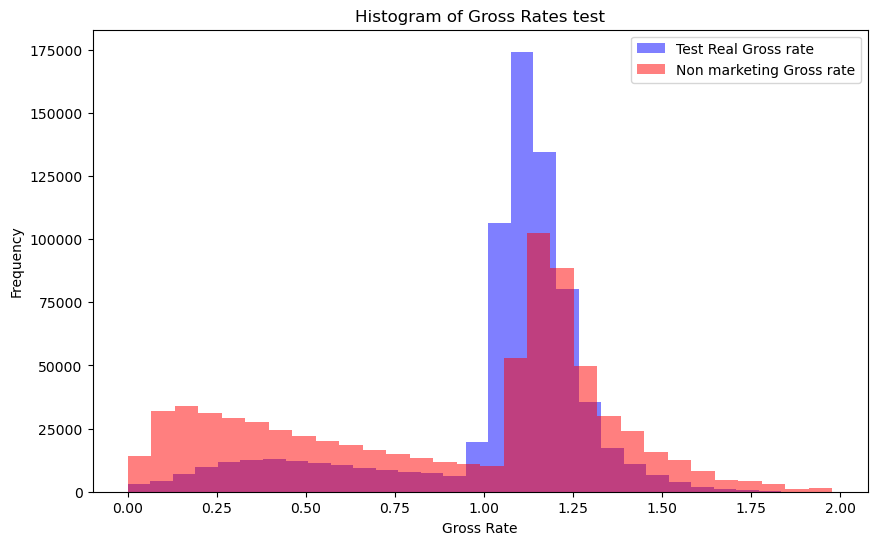

In [317]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(result['real_rate'], bins=30, alpha=0.5, label='Test Real Gross rate', color='blue')
plt.hist(result['non_marketing_rate'], bins=30, alpha=0.5, label='Non marketing Gross rate', color='red')

plt.title('Histogram of Gross Rates test')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
plt.savefig('/Users/kbh/Downloads/lending club/Histogram of gross rate real test.png',dpi=400)
plt.show()

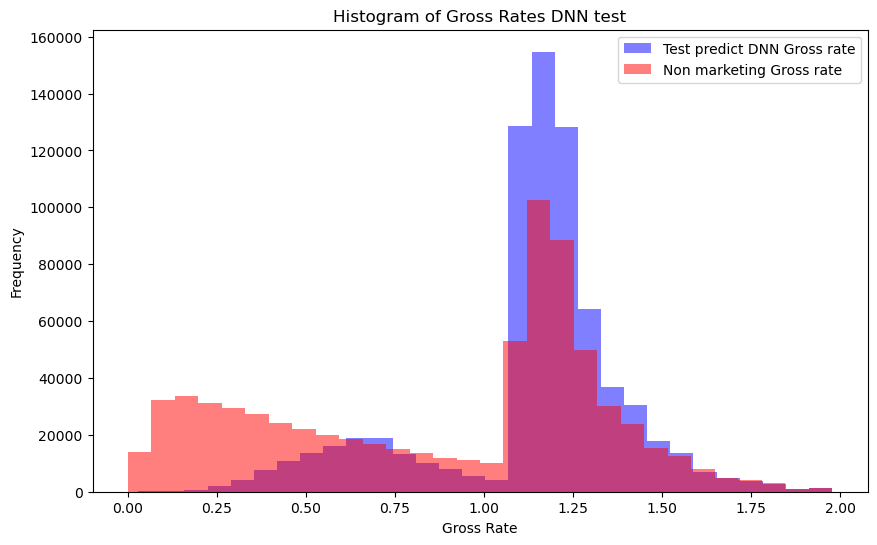

In [155]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(result['predict_DNN_rate'], bins=30, alpha=0.5, label='Test predict DNN Gross rate', color='blue')
plt.hist(result['non_marketing_rate'], bins=30, alpha=0.5, label='Non marketing Gross rate', color='red')

plt.title('Histogram of Gross Rates DNN test')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
plt.savefig('/Users/kbh/Downloads/lending club/Histogram of gross rate DNN test.png',dpi=400)
plt.show()

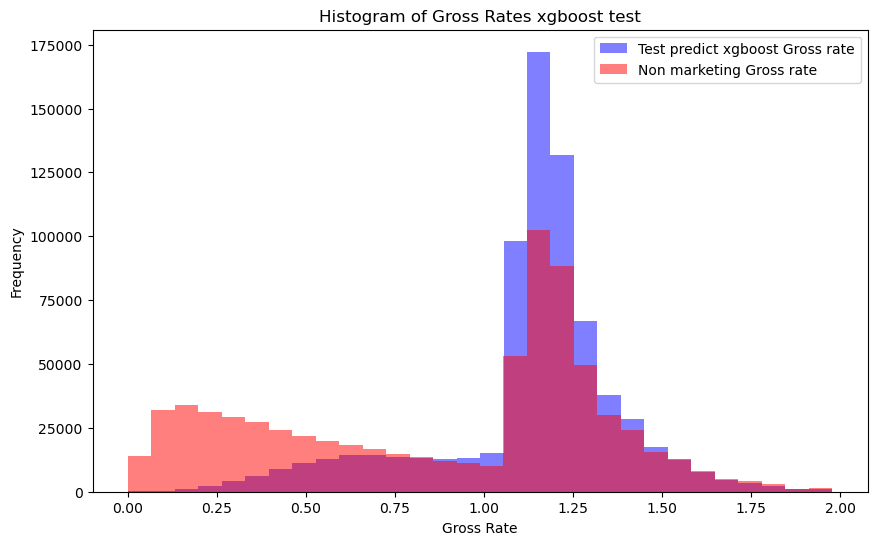

In [159]:
plt.close()
plt.ioff()
plt.figure(figsize=(10, 6))
plt.hist(result['predict_xgboost_rate'], bins=30, alpha=0.5, label='Test predict xgboost Gross rate', color='blue')
plt.hist(result['non_marketing_rate'], bins=30, alpha=0.5, label='Non marketing Gross rate', color='red')

plt.title('Histogram of Gross Rates xgboost test')
plt.xlabel('Gross Rate')
plt.ylabel('Frequency')

plt.legend()
plt.savefig('/Users/kbh/Downloads/lending club/Histogram of gross rate xgboost test.png',dpi=400)
plt.show()

In [365]:
etf_bond_result=selected_etf_bond_rate(result,etf_data,bond3yr,bond5yr)
result=pandas.concat([result,etf_bond_result],axis=1)
result.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,debt_settlement_flag,dnn_pred,xgboost_pred,real_target,DNN_result,xgboost_result,original_result,calc_installment,predict_DNN_rate,predict_xgboost_rate,non_marketing_rate,real_rate,type,rate
0,3697367,20000.0000,20000.0000,20000.0000,36,6.0300,608.7200,0,6.0000,MORTGAGE,125000.0000,Source Verified,Mar-2013,Fully Paid,n,debt_consolidation,12.5300,0.0000,Oct-1997,785.0000,789.0000,1.0000,0.0000,12.0000,0.0000,14172.0000,26.2000,42.0000,f,0.0000,0.0000,21913.5519,21913.5500,20000.0000,1913.5500,0.0000,0.0000,0.0000,2016-03,608.3500,2020-05,724.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,291526.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,54000.0000,0.0000,0.0000,0.0000,5.0000,26502.0000,35820.0000,26.9000,0.0000,0.0000,188.0000,165.0000,14.0000,5.0000,7.0000,14.0000,37.0000,6.0000,33.0000,0.0000,4.0000,6.0000,6.0000,20.0000,9.0000,8.0000,26.0000,6.0000,0.0000,0.0000,0.0000,1.0000,100.0000,0.0000,0.0000,0.0000,355384.0000,37905.0000,49000.0000,46184.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,N,1.0000,1.0000,1.0000,36,36,36,608.0000,1.0944,1.0944,1.0944,1.0957,Bond,1.0035
1,163922381,19125.0000,19125.0000,19125.0000,36,8.8100,606.4900,4,0.5000,MORTGAGE,65000.0000,Not Verified,Dec-2019,In Grace Period,n,debt_consolidation,13.5200,0.0000,Jul-2010,700.0000,704.0000,0.0000,0.0000,5.0000,0.0000,15583.0000,72.5000,11.0000,w,17245.9000,17245.9000,2411.9200,2411.9200,1879.1000,532.8200,0.0000,0.0000,0.0000,2020-05,606.4900,2020-05,709.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,167393.0000,0.0000,1.0000,0.0000,0.0000,27.0000,3195.0000,32.0000,0.0000,0.0000,7959.0000,60.0000,21500.0000,0.0000,2.0000,1.0000,2.0000,33479.0000,5917.0000,72.5000,0.0000,0.0000,70.0000,113.0000,43.0000,8.0000,2.0000,43.0000,37.0000,10.0000,33.0000,0.0000,3.0000,3.0000,3.0000,3.0000,5.0000,3.0000,4.0000,3.0000,0.0000,0.0000,0.0000,2.0000,100.0000,33.3000,0.0000,0.0000,181365.0000,18778.0000,21500.0000,10000.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,N,1.0000,1.0000,0.0983,36,36,4,606.0000,1.1407,1.1407,0.1267,0.1261,Bond,1.0161
2,13046178

In [449]:
def select_good_rate(loan_data,target:str) : 
    loans=loan_data
    loans['final_type'] = numpy.where(
        loans[target] > loans['rate'],
        'Loan',
        loans['type']
    )
    loans['selected_rate'] = numpy.where(
        loans[target] > loans['rate'],
        loans[target],
        loans['rate']
    )
    loans=loans.reset_index(drop=True)
    return loans

In [443]:
final_revenue=select_good_rate(result,'predict_DNN_rate')

In [447]:
final_revenue=select_good_rate(result,'predict_xgboost_rate')

In [451]:
final_revenue=select_good_rate(result,'non_marketing_rate')

In [393]:
# final_revenue.to_csv('/Users/kbh/Downloads/lending club/test_rate_out_current.csv',index=False)

In [457]:
final_revenue['DNN_selected_rate'].mean()

1.202169242674372

In [459]:
final_revenue['xgboost_selected_rate'].mean()

1.193069615108815

In [461]:
final_revenue['non_marketing_selected_rate'].mean()

1.1996491970721999

In [437]:
# result.drop(['final_type','selected_rate_xgboost','selected_rate','selected_DNN_rate','selected_xgboost_rate','selected_original_rate'],axis=1,inplace=True)

In [455]:
result.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,purpose,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,last_fico_range_high,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,debt_settlement_flag,dnn_pred,xgboost_pred,real_target,DNN_result,xgboost_result,original_result,calc_installment,predict_DNN_rate,predict_xgboost_rate,non_marketing_rate,real_rate,type,rate,DNN_final_type,DNN_selected_rate,xgboost_final_type,xgboost_selected_rate,non_marketing_final_type,non_marketing_selected_rate
0,3697367,20000.0000,20000.0000,20000.0000,36,6.0300,608.7200,0,6.0000,MORTGAGE,125000.0000,Source Verified,Mar-2013,Fully Paid,n,debt_consolidation,12.5300,0.0000,Oct-1997,785.0000,789.0000,1.0000,0.0000,12.0000,0.0000,14172.0000,26.2000,42.0000,f,0.0000,0.0000,21913.5519,21913.5500,20000.0000,1913.5500,0.0000,0.0000,0.0000,2016-03,608.3500,2020-05,724.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,291526.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,54000.0000,0.0000,0.0000,0.0000,5.0000,26502.0000,35820.0000,26.9000,0.0000,0.0000,188.0000,165.0000,14.0000,5.0000,7.0000,14.0000,37.0000,6.0000,33.0000,0.0000,4.0000,6.0000,6.0000,20.0000,9.0000,8.0000,26.0000,6.0000,0.0000,0.0000,0.0000,1.0000,100.0000,0.0000,0.0000,0.0000,355384.0000,37905.0000,49000.0000,46184.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,N,1.0000,1.0000,1.0000,36,36,36,608.0000,1.0944,1.0944,1.0944,1.0957,Bond,1.0035,Loan,1.0944,Loan,1.0944,Loan,1.0944
1,163922381,19125.0000,19125.0000,19125.0000,36,8.8100,606.4900,4,0.5000,MORTGAGE,65000.0000,Not Verified,Dec-2019,In Grace Period,n,debt_consolidation,13.5200,0.0000,Jul-2010,700.0000,704.0000,0.0000,0.0000,5.0000,0.0000,15583.0000,72.5000,11.0000,w,17245.9000,17245.9000,2411.9200,2411.9200,1879.1000,532.8200,0.0000,0.0000,0.0000,2020-05,606.4900,2020-05,709.0000,0.0000,0.0000,1.0000,Individual,0.0000,0.0000,0,0.0000,0.0000,167393.0000,0.0000,1.0000,0.0000,0.0000,27.0000,3195.0000,32.0000,0.0000,0.0000,7959.0000,60.0000,21500.0000,0.0000,2.0000,1.0000,2.0000,33479.0000,5917.0000,72.5000,0.0000,0.0000,70.0000,113.0000,43.0000,8.0000,2.0000,43.0000,37.0000,10.0000,33.0000,0.0000,3.0000,3.0000,3.0000,3.0000,5.0000,3.0000,4.0000,3.0000,0.0000,0.0000,0.0000,2.0000,100.0000,33.3000,0.0000,0.0000,181365.0000,18778.0000,21500.0000,10000.0000,0.0000